# Portfolio Optimization with TSFM Forecasts — Walk-Forward Backtest

This notebook builds the complete AI-driven portfolio pipeline:

1. Load the S&P 500 + macro dataset from notebooks/02
2. Generate μ (expected returns) via Chronos-2 + TimesFM 1.0 ensemble
3. Estimate Σ (covariance) via GARCH(1,1) + historical correlation (DCC approximation)
4. Maximize Sharpe Ratio using cvxpy SOCP reformulation
5. Walk-forward backtest (12-month, monthly rebalancing) vs Equal-Weight baseline
6. Visualize cumulative returns, dynamic weights, and risk metrics

**Note on TimesFM version:** `google/timesfm-2.5` requires `timesfm>=2.0` and Python 3.11+.
This notebook uses `google/timesfm-1.0-200m-pytorch` (stable with our Python 3.10 venv).
Upgrade path: `pip install --upgrade timesfm` after upgrading to Python 3.11.

In [1]:
import sys
print(sys.executable)
print(sys.version)

/home/pj/dev/miniconda3/envs/hfm-data/bin/python
3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0]


In [2]:
import importlib

_deps = {
    'arch': 'arch',
    'cvxpy': 'cvxpy',
    'chronos': 'chronos-forecasting',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'plotly': 'plotly',
}
_optional_deps = {
    'timesfm': 'timesfm',
}

missing = []
for mod, pkg in _deps.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(pkg)

if missing:
    raise RuntimeError(
        'Missing dependencies: '
        + ', '.join(sorted(set(missing)))
        + "\nInstall first: python -m pip install --break-system-packages --user -r requirements.txt"
    )

import warnings
warnings.filterwarnings('ignore')
print('Dependency check complete.')

/home/pj/dev/miniconda3/envs/hfm-data/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependency check complete.


## 1. Imports & Configuration

Key config constants:
- `TICKERS_N=10` — top 10 tickers by data coverage
- `BACKTEST_DAYS=252` — ~12 months walk-forward window
- `REBAL_FREQ=21` — monthly rebalancing
- `CHRONOS_WEIGHT=0.5` — equal blend of Chronos-2 and TimesFM
- `RF_ANNUAL=0.05` — annualised risk-free rate
- `FAST_MODE=True` — skip real TSFM inference, use historical μ proxy

In [3]:
import sys, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import cvxpy as cp
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from arch import arch_model
from chronos import Chronos2Pipeline
import torch

try:
    import timesfm
    TIMESFM_AVAILABLE = True
except ImportError:
    timesfm = None
    TIMESFM_AVAILABLE = False

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})

# ── Configuration ─────────────────────────────────────────────────
DATA_PATH       = 'data/sp500_macro_master.csv'
TICKERS_N       = 10
BACKTEST_DAYS   = 252
REBAL_FREQ      = 21
CHRONOS_WEIGHT  = 0.5
RF_ANNUAL       = 0.05
RF_DAILY        = RF_ANNUAL / 252
FAST_MODE       = False # True # False

if not TIMESFM_AVAILABLE:
    FAST_MODE = True
    CHRONOS_WEIGHT = 1.0

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if not TIMESFM_AVAILABLE:
    print('TimesFM unavailable on this runtime. Forcing FAST_MODE=True and Chronos-only weights.')
if FAST_MODE:
    print(f'FAST_MODE: {FAST_MODE}  ⚡ Using historical μ proxy')
else:
    print(f'FAST_MODE: {FAST_MODE}  🤖 Running real TSFM inference (slow)')
print(f'Config: {TICKERS_N} tickers | {BACKTEST_DAYS}d backtest | {REBAL_FREQ}d rebalance | Chronos={CHRONOS_WEIGHT:.0%}/TimesFM={1-CHRONOS_WEIGHT:.0%}')

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 16:42:22) [GCC 14.3.0].
Device: cuda
FAST_MODE: False  🤖 Running real TSFM inference (slow)
Config: 10 tickers | 252d backtest | 21d rebalance | Chronos=50%/TimesFM=50%


In [4]:
from pathlib import Path

path_candidates = [
    Path('data/sp500_macro_master.csv'),
    Path('../data/sp500_macro_master.csv'),
    Path('../../data/sp500_macro_master.csv'),
]

resolved_path = next((p for p in path_candidates if p.exists()), None)
if resolved_path is None:
    checked = '\n'.join(str(p.resolve()) for p in path_candidates)
    raise FileNotFoundError(f'sp500_macro_master.csv를 찾을 수 없습니다. 확인한 경로:\n{checked}')

DATA_PATH = resolved_path
print(f'DATA_PATH resolved: {DATA_PATH.resolve()}')

DATA_PATH resolved: /home/pj/dev/HFM_Implementation/data/sp500_macro_master.csv


## 2. Data Loading & Ticker Selection

We load the pre-built master CSV and select the top 10 tickers by data completeness
(number of rows). Using coverage-ranked tickers ensures no gaps in the backtest window.

In [5]:
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

coverage = df.groupby('Ticker')['Close'].count().sort_values(ascending=False)
TICKERS  = coverage.head(TICKERS_N).index.tolist()

print(f'Dataset: {len(df):,} rows | {df["Ticker"].nunique()} tickers | '
      f'{df["Date"].min().date()} \u2192 {df["Date"].max().date()}')
print(f'\nTop {TICKERS_N} tickers by coverage:')
sector_map = df[['Ticker','Sector']].drop_duplicates().set_index('Ticker')['Sector'].to_dict()
for t in TICKERS:
    print(f'  {t:<6}  {coverage[t]:>4} days  [{sector_map.get(t,"?")}]')

price_df = (
    df[df['Ticker'].isin(TICKERS)]
    .pivot_table(index='Date', columns='Ticker', values='Close')
    .sort_index()
    .ffill()
    .dropna()
)
print(f'\nPrice matrix: {price_df.shape}  ({price_df.index[0].date()} \u2192 {price_df.index[-1].date()})')
print(price_df.tail(3).round(2))

Dataset: 123,505 rows | 99 tickers | 2021-03-08 → 2026-03-06

Top 10 tickers by coverage:
  AAPL    1256 days  [Technology]
  ADBE    1256 days  [Technology]
  ACN     1256 days  [Technology]
  DHR     1256 days  [Healthcare]
  ETN     1256 days  [Industrials]
  ADI     1256 days  [Technology]
  ADP     1256 days  [Technology]
  AMAT    1256 days  [Technology]
  AMD     1256 days  [Technology]
  AMGN    1256 days  [Healthcare]

Price matrix: (1256, 10)  (2021-03-08 → 2026-03-06)
Ticker        AAPL    ACN    ADBE     ADI     ADP    AMAT     AMD    AMGN  \
Date                                                                        
2026-03-04  262.52  210.0  273.12  341.51  217.16  357.76  202.07  379.27   
2026-03-05  260.29  214.0  281.74  329.72  222.70  346.53  199.45  367.60   
2026-03-06  257.46  215.0  283.62  315.81  226.24  324.74  192.43  369.53   

Ticker         DHR     ETN  
Date                        
2026-03-04  204.73  354.46  
2026-03-05  202.00  354.79  
2026-03-06  19

## 3. GARCH Covariance Estimator

We approximate the DCC-GARCH covariance matrix using:
- **GARCH(1,1)** per-ticker → conditional volatility σᵢ (annualised)
- **Historical correlation** matrix R (252-day rolling window)
- **Σ = D · R · D** where D = diag(σ₁, ..., σₙ)

This captures time-varying volatility while keeping the covariance matrix PSD.

In [6]:
def garch_covariance(returns_df: pd.DataFrame) -> np.ndarray:
    """
    DCC-approximated covariance: GARCH(1,1) variances + historical correlation.
    Returns annualised covariance matrix (n \u00d7 n numpy array).
    """
    garch_vol = {}
    for col in returns_df.columns:
        r = returns_df[col].dropna() * 100
        try:
            am  = arch_model(r, vol='GARCH', p=1, q=1, rescale=False)
            res = am.fit(disp='off', show_warning=False)
            daily_vol         = res.conditional_volatility.iloc[-1] / 100
            garch_vol[col]    = daily_vol * np.sqrt(252)
        except Exception:
            garch_vol[col]    = returns_df[col].std() * np.sqrt(252)

    corr = returns_df.corr().fillna(0).values
    np.fill_diagonal(corr, 1.0)
    vols = np.array([garch_vol[c] for c in returns_df.columns])
    D    = np.diag(vols)
    cov  = D @ corr @ D
    cov  = (cov + cov.T) / 2 + 1e-7 * np.eye(len(vols))
    return cov

returns_all = np.log(price_df / price_df.shift(1)).dropna()
cov_test    = garch_covariance(returns_all.tail(252))
print(f'GARCH cov shape: {cov_test.shape}')
print(f'Diagonal (annualised vol\u00b2): {np.diag(cov_test).round(4)}')
print(f'Implied vols:               {np.sqrt(np.diag(cov_test)).round(3)}')

GARCH cov shape: (10, 10)
Diagonal (annualised vol²): [0.0685 0.1776 0.0848 0.1444 0.054  0.2444 0.3735 0.0876 0.0678 0.0893]
Implied vols:               [0.262 0.421 0.291 0.38  0.232 0.494 0.611 0.296 0.26  0.299]


## 4. TSFM Ensemble Forecasting for μ

Two modes:

**FAST_MODE = True** — skips model inference. Uses 252-day mean log return
as the μ proxy. Suitable for dry-run / structural validation.

**FAST_MODE = False** — loads Chronos-2 and TimesFM 1.0 on GPU (bfloat16).
For each ticker: generates 21-day ahead forecast (1 month), takes the median
as the expected price path, derives μ as the annualised expected log return.
Both models are loaded once and reused across all backtest rebalancing periods.

In [9]:
chronos_pipeline = None
timesfm_model    = None

if not FAST_MODE:
    print('Loading Chronos-2...')
    t0 = time.perf_counter()
    chronos_pipeline = Chronos2Pipeline.from_pretrained(
        'amazon/chronos-2',
        device_map=DEVICE,
        torch_dtype=torch.bfloat16,
    )
    print(f'  Chronos-2 loaded in {time.perf_counter()-t0:.1f}s')

    print('Loading TimesFM 1.0...')
    t0 = time.perf_counter()
    tfm_hparams = timesfm.TimesFmHparams(
        backend='gpu',
        per_core_batch_size=32,
        horizon_len=128,
        num_layers=20,
        model_dims=1280,
        use_positional_embedding=True,
        context_len=512,
    )
    tfm_ckpt = timesfm.TimesFmCheckpoint(
        huggingface_repo_id='google/timesfm-1.0-200m-pytorch'
    )
    timesfm_model = timesfm.TimesFm(hparams=tfm_hparams, checkpoint=tfm_ckpt)
    print(f'  TimesFM loaded in {time.perf_counter()-t0:.1f}s')
    if DEVICE == 'cuda':
        print(f'  VRAM used: {torch.cuda.memory_allocated()/1024**2:.0f} MB')
else:
    print('FAST_MODE=True \u2014 skipping model load.')

def tsfm_mu_forecast(
    price_window: pd.DataFrame,
    horizon: int = 21,
    chronos_weight: float = CHRONOS_WEIGHT,
) -> pd.Series:
    """
    Compute annualised expected return \u03bc for each ticker using TSFM ensemble.

    FAST_MODE: returns 252-day mean log return * 252 (annualised).
    Full mode:  Chronos-2 median + TimesFM median blend \u2192 expected price \u2192 \u03bc.
    """
    if FAST_MODE or (chronos_pipeline is None and timesfm_model is None):
        log_ret = np.log(price_window / price_window.shift(1)).dropna()
        return (log_ret.mean() * 252).rename('mu')

    mu_dict = {}
    for ticker in price_window.columns:
        prices  = price_window[ticker].dropna().values.astype(np.float32)
        context = torch.tensor(prices[-512:], dtype=torch.float32)
        last_px = float(prices[-1])

        with torch.inference_mode():
            inputs_3d = context.unsqueeze(0).unsqueeze(0)
            fc_c    = chronos_pipeline.predict(
                inputs=inputs_3d, prediction_length=horizon,
                limit_prediction_length=False,
            )
        chronos_med = fc_c[0][0, 4, :horizon].cpu().numpy()

        pt_fc, qt_fc = timesfm_model.forecast(inputs=[prices[-512:]], freq=[0])
        tfm_med      = pt_fc[0, :horizon]

        ens_med  = chronos_weight * chronos_med + (1 - chronos_weight) * tfm_med
        exp_px   = ens_med[-1]
        mu_daily = np.log(exp_px / last_px) / horizon
        mu_dict[ticker] = mu_daily * 252

        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    return pd.Series(mu_dict, name='mu')

print('\nRunning \u03bc forecast (test)...')
t0  = time.perf_counter()
mu_test = tsfm_mu_forecast(price_df.tail(252 + 21).head(252))
print(f'Done in {time.perf_counter()-t0:.1f}s')
print('\nExpected annualised returns (\u03bc):')
for t, v in mu_test.sort_values(ascending=False).items():
    print(f'  {t:<6}  {v*100:+.2f}%  [{sector_map.get(t,"?")}]')

Loading Chronos-2...
  Chronos-2 loaded in 1.2s
Loading TimesFM 1.0...


Fetching 3 files: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 25997.75it/s]


  TimesFM loaded in 3.5s
  VRAM used: 1250 MB

Running μ forecast (test)...
Done in 1.1s

Expected annualised returns (μ):
  ACN     -3.30%  [Technology]
  DHR     -13.98%  [Healthcare]
  ETN     -15.15%  [Industrials]
  ADP     -21.55%  [Technology]
  ADBE    -23.09%  [Technology]
  AAPL    -27.83%  [Technology]
  ADI     -58.08%  [Technology]
  AMAT    -60.45%  [Technology]
  AMGN    -88.45%  [Healthcare]
  AMD     -117.63%  [Technology]


## 5. Sharpe-Maximising Portfolio — cvxpy SOCP

The Sharpe Ratio is non-convex in w. We use the **Tobin/Dinkelbach reformulation**:

Let **y = w · κ** where **κ = 1 / √(wᵀΣw)** (inverse portfolio volatility).

The equivalent SOCP is:
> **Maximise** (μ − rf)ᵀ y  
> **Subject to** yᵀΣy ≤ 1, y ≥ 0

Then recover **w = y / Σyᵢ** (re-normalise to budget constraint).

This is a standard second-order cone program solvable in milliseconds with OSQP.

In [10]:
def max_sharpe_portfolio(
    mu: pd.Series,
    cov: np.ndarray,
    rf_daily: float = RF_DAILY,
    max_weight: float = 0.40,
) -> pd.Series:
    """
    Maximise Sharpe Ratio via SOCP reformulation (Tobin separation).
    Falls back to equal-weight on solver failure.
    """
    n          = len(mu)
    tickers    = mu.index.tolist()
    rf_annual  = rf_daily * 252
    mu_excess  = (mu.values - rf_annual).astype(float)
    cov_mat    = cov.astype(float)

    y = cp.Variable(n, nonneg=True)

    objective   = cp.Maximize(mu_excess @ y)
    constraints = [
        cp.quad_form(y, cp.psd_wrap(cov_mat)) <= 1,
        y <= max_weight * cp.sum(y),
    ]
    prob = cp.Problem(objective, constraints)

    for solver in [cp.OSQP, cp.SCS, cp.ECOS]:
        try:
            prob.solve(solver=solver, warm_start=True)
            if prob.status in ('optimal', 'optimal_inaccurate') and y.value is not None:
                w = np.maximum(y.value, 0)
                total = w.sum()
                if total > 1e-8:
                    return pd.Series(w / total, index=tickers)
        except Exception:
            continue

    print('  \u26a0\ufe0f  Solver failed \u2014 using equal weight fallback')
    return pd.Series(np.ones(n) / n, index=tickers)

cov_test_mat = garch_covariance(returns_all.tail(252))
w_test       = max_sharpe_portfolio(mu_test, cov_test_mat)
print('Optimal weights (Sharpe-max):')
for t, w in w_test.sort_values(ascending=False).items():
    print(f'  {t:<6}  {w*100:.1f}%')

sharpe_num = (w_test @ mu_test - RF_ANNUAL)
sharpe_den = np.sqrt(w_test.values @ cov_test_mat @ w_test.values)
print(f'\nEstimated Sharpe (ex-ante): {sharpe_num / sharpe_den:.3f}')

Optimal weights (Sharpe-max):
  AMD     41.9%
  AMAT    34.2%
  ETN     13.6%
  ADI     10.2%
  ACN     0.0%
  AAPL    0.0%
  ADP     0.0%
  ADBE    0.0%
  AMGN    0.0%
  DHR     0.0%

Estimated Sharpe (ex-ante): -1.915


## 6. Walk-Forward Backtest

We simulate monthly rebalancing over the final 12 months of our dataset.

At each rebalancing date t:
1. **Train window**: 252 trading days ending at t
2. **μ estimation**: TSFM ensemble forecast over next 21 days
3. **Σ estimation**: GARCH(1,1) covariance on train window
4. **Optimise**: Sharpe-max QP → weights wₜ
5. **Apply**: hold wₜ for next 21 days, record daily P&L

Baseline: **Equal-Weight (EW)** — 1/N fixed throughout.

In [11]:
def run_backtest(
    price_df:       pd.DataFrame,
    backtest_days:  int  = BACKTEST_DAYS,
    rebal_freq:     int  = REBAL_FREQ,
    train_window:   int  = 252,
) -> dict:
    """
    Walk-forward monthly-rebalancing backtest.

    Returns dict with:
        ai_returns   : pd.Series — daily AI portfolio returns
        ew_returns   : pd.Series — daily EW portfolio returns
        weights_hist : list of (date, pd.Series) — weights at each rebalance
        rebal_dates  : list of pd.Timestamp
    """
    n          = len(price_df.columns)
    all_dates  = price_df.index
    bt_start   = len(all_dates) - backtest_days
    bt_dates   = all_dates[bt_start:]

    log_ret    = np.log(price_df / price_df.shift(1)).dropna()

    ai_rets    = []
    ew_rets    = []
    dates_out  = []
    weights_hist  = []
    rebal_dates   = []

    current_weights = pd.Series(np.ones(n) / n, index=price_df.columns)

    print(f'Backtest: {bt_dates[0].date()} \u2192 {bt_dates[-1].date()}')
    print(f'  {len(bt_dates)} days | {len(bt_dates)//rebal_freq} rebalancing periods')

    step = 0
    for i, date in enumerate(bt_dates):
        if i % rebal_freq == 0:
            row_idx = all_dates.get_loc(date)
            if row_idx < train_window:
                continue

            train_px = price_df.iloc[row_idx - train_window : row_idx]
            train_ret = log_ret.iloc[row_idx - train_window : row_idx]

            mu = tsfm_mu_forecast(train_px, horizon=rebal_freq)

            cov = garch_covariance(train_ret)

            current_weights = max_sharpe_portfolio(mu, cov)
            weights_hist.append((date, current_weights.copy()))
            rebal_dates.append(date)

            step += 1
            sharpe_ex = ((current_weights @ mu - RF_ANNUAL) /
                         np.sqrt(current_weights.values @ cov @ current_weights.values))
            top2 = current_weights.nlargest(2)
            print(f'  [{step:>2}] {date.date()}  ex-ante Sharpe={sharpe_ex:.2f}  '
                  + '  '.join(f'{t}:{w*100:.0f}%' for t, w in top2.items()))

        if date in log_ret.index:
            day_ret = log_ret.loc[date]
            ai_ret  = float(current_weights @ day_ret.reindex(current_weights.index).fillna(0))
            ew_ret  = float(day_ret.mean())
            ai_rets.append(ai_ret)
            ew_rets.append(ew_ret)
            dates_out.append(date)

    ai_series = pd.Series(ai_rets, index=dates_out, name='AI Portfolio')
    ew_series = pd.Series(ew_rets, index=dates_out, name='Equal Weight')

    return {
        'ai_returns':   ai_series,
        'ew_returns':   ew_series,
        'weights_hist': weights_hist,
        'rebal_dates':  rebal_dates,
    }

print('Starting walk-forward backtest...\n')
t0      = time.perf_counter()
results = run_backtest(price_df)
elapsed = time.perf_counter() - t0
print(f'\nBacktest complete in {elapsed:.1f}s')

Starting walk-forward backtest...

Backtest: 2025-03-06 → 2026-03-06
  252 days | 12 rebalancing periods
  [ 1] 2025-03-06  ex-ante Sharpe=0.04  ADBE:40%  AMAT:40%
  [ 2] 2025-04-04  ex-ante Sharpe=1.52  ADBE:40%  ADP:31%
  [ 3] 2025-05-06  ex-ante Sharpe=-1.25  AMAT:37%  AMD:29%
  [ 4] 2025-06-05  ex-ante Sharpe=-1.23  AMD:36%  AMAT:36%
  [ 5] 2025-07-08  ex-ante Sharpe=-2.21  AMAT:46%  AMD:28%
  [ 6] 2025-08-06  ex-ante Sharpe=-0.82  ETN:40%  AMD:29%
  [ 7] 2025-09-05  ex-ante Sharpe=-2.18  ACN:26%  AMGN:24%
  [ 8] 2025-10-06  ex-ante Sharpe=-2.08  AMD:51%  AMAT:33%
  [ 9] 2025-11-04  ex-ante Sharpe=-1.77  AMGN:28%  DHR:20%
  [10] 2025-12-04  ex-ante Sharpe=-1.70  AMD:38%  AMAT:29%
  [11] 2026-01-06  ex-ante Sharpe=0.18  ETN:40%  AMGN:40%
  [12] 2026-02-05  ex-ante Sharpe=-2.76  AMGN:46%  ADP:18%

Backtest complete in 15.2s


## 7. Performance Metrics

In [12]:
def performance_metrics(returns: pd.Series, rf_daily: float = RF_DAILY) -> dict:
    """Compute annualised return, volatility, Sharpe, Max Drawdown, Calmar."""
    r          = returns.dropna()
    ann_ret    = r.mean() * 252
    ann_vol    = r.std()  * np.sqrt(252)
    sharpe     = (ann_ret - RF_ANNUAL) / ann_vol if ann_vol > 0 else 0.0
    cum        = (1 + r).cumprod()
    rolling_max = cum.cummax()
    drawdown    = (cum - rolling_max) / rolling_max
    max_dd      = drawdown.min()
    calmar      = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {
        'Ann. Return (%)':   round(ann_ret * 100, 2),
        'Ann. Vol (%)':      round(ann_vol * 100, 2),
        'Sharpe Ratio':      round(sharpe, 3),
        'Max Drawdown (%)':  round(max_dd * 100, 2),
        'Calmar Ratio':      round(calmar, 3),
        'Total Return (%)':  round(((1 + r).prod() - 1) * 100, 2),
    }

def turnover(weights_hist: list) -> float:
    """Average absolute weight change per rebalancing period."""
    if len(weights_hist) < 2:
        return 0.0
    turns = []
    for (_, w1), (_, w2) in zip(weights_hist[:-1], weights_hist[1:]):
        turns.append((w2 - w1).abs().sum())
    return float(np.mean(turns))

ai_metrics = performance_metrics(results['ai_returns'])
ew_metrics = performance_metrics(results['ew_returns'])
to_val     = turnover(results['weights_hist'])

metrics_df = pd.DataFrame({
    'AI Portfolio': ai_metrics,
    'Equal Weight': ew_metrics,
}).T
metrics_df['Turnover (avg)'] = [round(to_val, 3), '\u2014']
print('Performance Summary:')
print(metrics_df.to_string())

Performance Summary:
              Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio  Total Return (%) Turnover (avg)
AI Portfolio            57.34         32.75         1.598            -20.83         2.752             68.22          1.239
Equal Weight             8.97         24.25         0.164            -19.51         0.460              6.25              —


## 8. Visualization — Three Charts

### Chart 1: Cumulative Returns

/home/pj/dev/HFM_Implementation


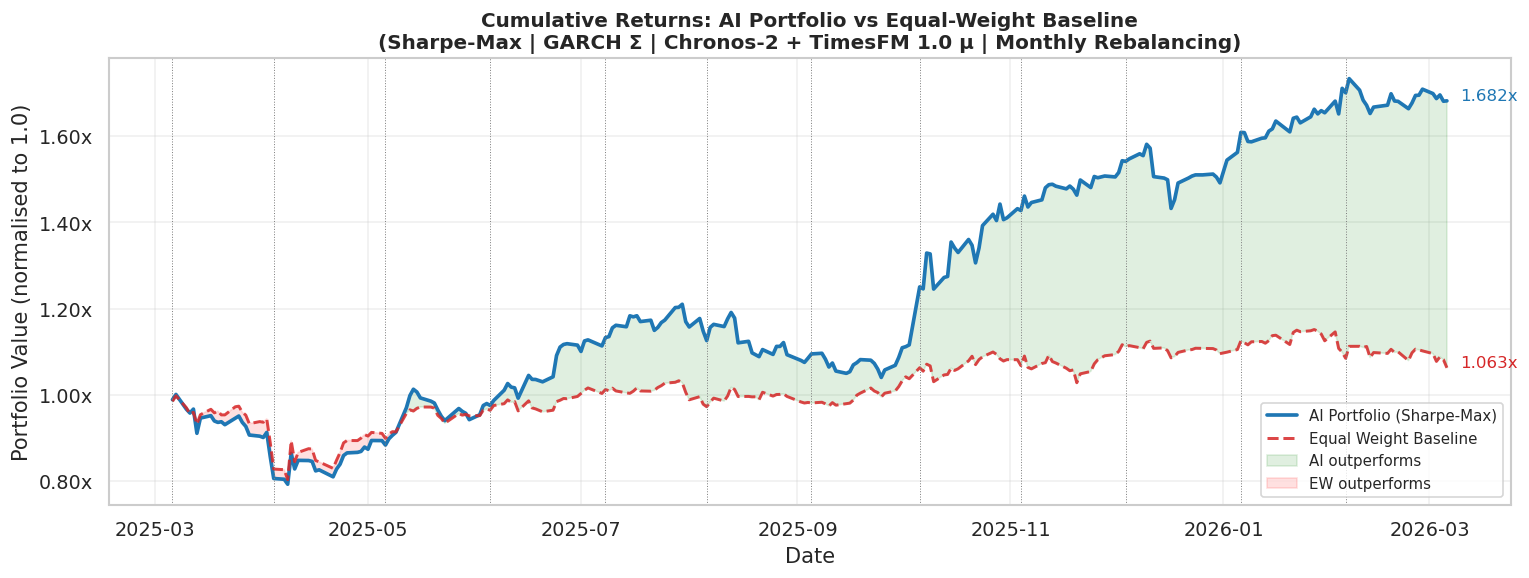

AI total return:  +68.22%
EW total return:  +6.25%
Alpha:            +61.97pp


In [13]:
import os; print(os.getcwd())

ai_ret = results['ai_returns']
ew_ret = results['ew_returns']

ai_cum = (1 + ai_ret).cumprod()
ew_cum = (1 + ew_ret).cumprod()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(ai_cum.index, ai_cum.values, linewidth=2.2,
        color='#1f77b4', label='AI Portfolio (Sharpe-Max)')
ax.plot(ew_cum.index, ew_cum.values, linewidth=1.8,
        color='#d62728', linestyle='--', alpha=0.85, label='Equal Weight Baseline')

ax.fill_between(ai_cum.index, ai_cum.values, ew_cum.values,
                where=(ai_cum.values >= ew_cum.values),
                alpha=0.12, color='green', label='AI outperforms')
ax.fill_between(ai_cum.index, ai_cum.values, ew_cum.values,
                where=(ai_cum.values < ew_cum.values),
                alpha=0.12, color='red', label='EW outperforms')

for rd in results['rebal_dates']:
    ax.axvline(x=rd, color='gray', linewidth=0.6, linestyle=':')

ai_final = ai_cum.iloc[-1]
ew_final = ew_cum.iloc[-1]
ax.annotate(f'{ai_final:.3f}x', xy=(ai_cum.index[-1], ai_final),
            xytext=(8, 0), textcoords='offset points', color='#1f77b4', fontsize=10)
ax.annotate(f'{ew_final:.3f}x', xy=(ew_cum.index[-1], ew_final),
            xytext=(8, 0), textcoords='offset points', color='#d62728', fontsize=10)

ax.set_title('Cumulative Returns: AI Portfolio vs Equal-Weight Baseline\n'
             f'(Sharpe-Max | GARCH \u03a3 | Chronos-2 + TimesFM 1.0 \u03bc | Monthly Rebalancing)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (normalised to 1.0)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fx'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/03_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AI total return:  {(ai_final-1)*100:+.2f}%')
print(f'EW total return:  {(ew_final-1)*100:+.2f}%')
print(f'Alpha:            {(ai_final-ew_final)*100:+.2f}pp')

### Chart 2: Dynamic Asset Weight Changes (Stacked Area)

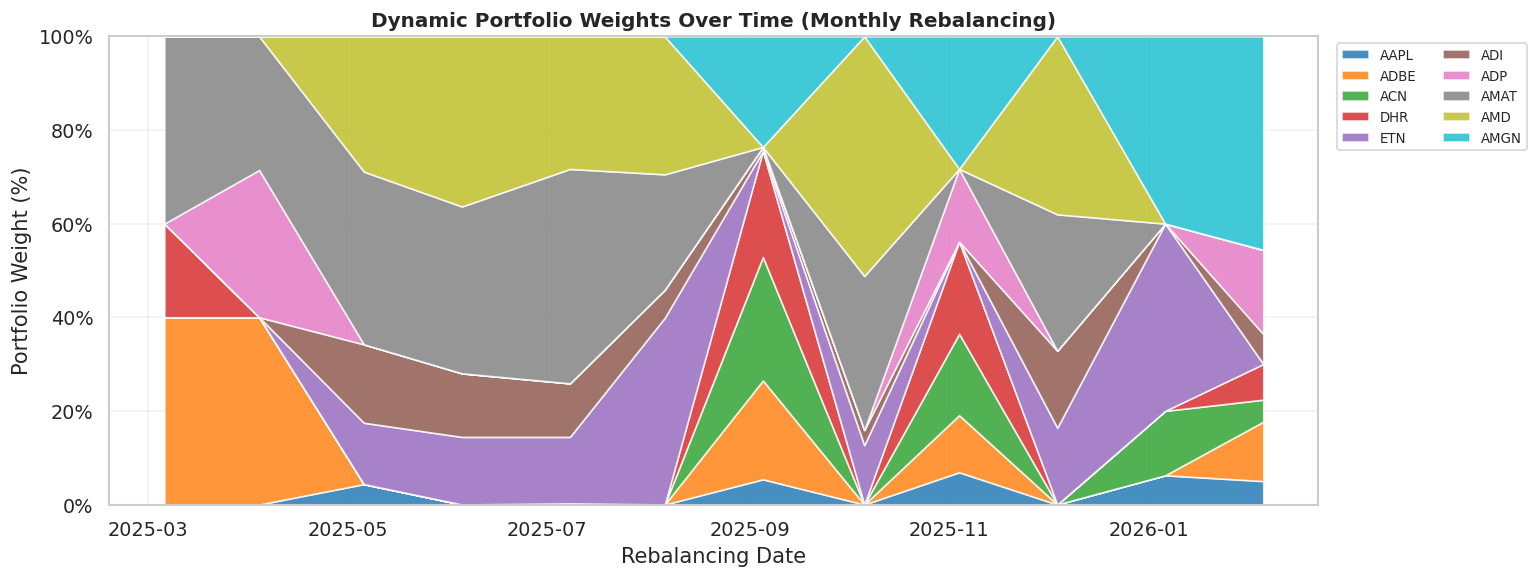

Weight evolution:
Ticker       AAPL    ACN   ADBE    ADI    ADP   AMAT    AMD   AMGN    DHR    ETN
2025-03-06  0.000  0.000  0.400  0.000  0.000  0.400  0.000  0.000  0.200  0.000
2025-04-04  0.000  0.000  0.400  0.000  0.315  0.285  0.000  0.000  0.000  0.000
2025-05-06  0.044  0.000  0.000  0.167  0.000  0.369  0.289  0.000  0.000  0.131
2025-06-05  0.000  0.000  0.000  0.136  0.000  0.356  0.363  0.000  0.000  0.144
2025-07-08  0.003  0.000  0.000  0.114  0.000  0.458  0.283  0.000  0.000  0.142
2025-08-06  0.000  0.000  0.000  0.060  0.000  0.246  0.295  0.000  0.000  0.399
2025-09-05  0.054  0.264  0.211  0.008  0.000  0.000  0.000  0.236  0.227  0.000
2025-10-06  0.000  0.000  0.000  0.032  0.000  0.329  0.512  0.000  0.000  0.127
2025-11-04  0.069  0.174  0.122  0.000  0.155  0.000  0.000  0.283  0.197  0.000
2025-12-04  0.000  0.000  0.000  0.165  0.000  0.291  0.380  0.000  0.000  0.164
2026-01-06  0.062  0.138  0.000  0.000  0.000  0.000  0.000  0.400  0.000  0.400
2026-02-05

In [14]:
if results['weights_hist']:
    rebal_dates_list = [d for d, _ in results['weights_hist']]
    weights_matrix   = pd.DataFrame(
        [w.values for _, w in results['weights_hist']],
        index=rebal_dates_list,
        columns=price_df.columns,
    )

    palette = sns.color_palette('tab10', n_colors=TICKERS_N)
    fig, ax = plt.subplots(figsize=(13, 5))

    ax.stackplot(
        weights_matrix.index,
        [weights_matrix[t].values for t in TICKERS],
        labels=TICKERS,
        colors=palette,
        alpha=0.82,
    )

    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title('Dynamic Portfolio Weights Over Time (Monthly Rebalancing)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Rebalancing Date')
    ax.set_ylabel('Portfolio Weight (%)')
    ax.legend(loc='upper left', fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1))
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig('notebooks/03_dynamic_weights.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Weight evolution:')
    print(weights_matrix.round(3).to_string())
else:
    print('No rebalancing periods recorded \u2014 check backtest config.')

### Chart 3: Risk–Return Metrics Dashboard

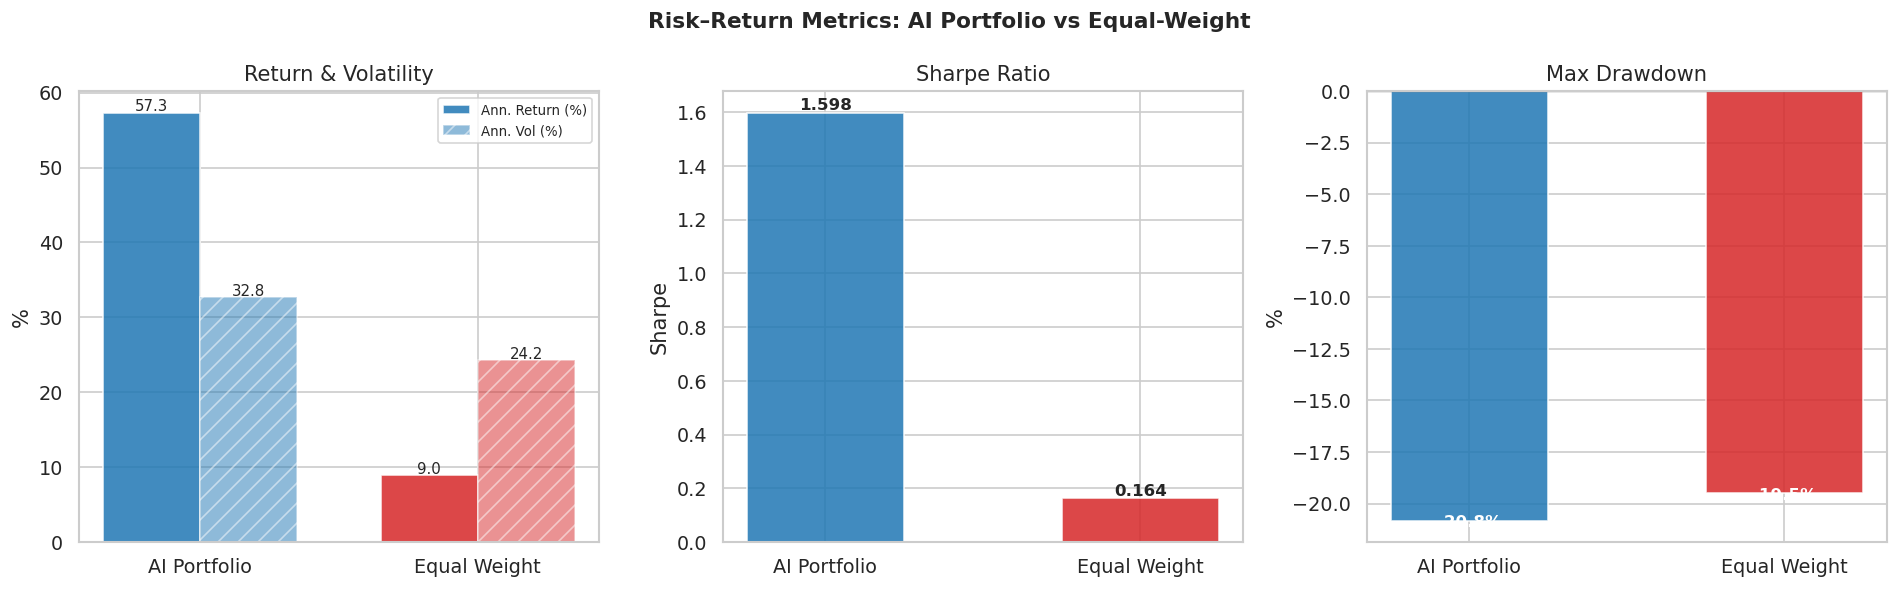


Full performance table:
              Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio  Total Return (%) Turnover (avg)
AI Portfolio            57.34         32.75         1.598            -20.83         2.752             68.22          1.239
Equal Weight             8.97         24.25         0.164            -19.51         0.460              6.25              —


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

labels   = ['AI Portfolio', 'Equal Weight']
colors   = ['#1f77b4', '#d62728']
alphas   = [0.85, 0.70]

ret_vals = [ai_metrics['Ann. Return (%)'], ew_metrics['Ann. Return (%)']]
vol_vals = [ai_metrics['Ann. Vol (%)'],    ew_metrics['Ann. Vol (%)']]

x = np.array([0, 1])
w = 0.35
axes[0].bar(x - w/2, ret_vals, w, label='Ann. Return (%)',
            color=colors, alpha=0.85, edgecolor='white')
axes[0].bar(x + w/2, vol_vals, w, label='Ann. Vol (%)',
            color=colors, alpha=0.50, hatch='//', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('Return & Volatility'); axes[0].set_ylabel('%')
axes[0].legend(fontsize=8)
for i, (r, v) in enumerate(zip(ret_vals, vol_vals)):
    axes[0].text(i-w/2, r+0.2, f'{r:.1f}', ha='center', fontsize=9)
    axes[0].text(i+w/2, v+0.2, f'{v:.1f}', ha='center', fontsize=9)

sharpe_vals = [ai_metrics['Sharpe Ratio'], ew_metrics['Sharpe Ratio']]
bars = axes[1].bar(labels, sharpe_vals, color=colors, alpha=0.85,
                   edgecolor='white', width=0.5)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('Sharpe Ratio'); axes[1].set_ylabel('Sharpe')
for bar, v in zip(bars, sharpe_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

dd_vals = [ai_metrics['Max Drawdown (%)'], ew_metrics['Max Drawdown (%)']]
bars = axes[2].bar(labels, dd_vals, color=colors, alpha=0.85,
                   edgecolor='white', width=0.5)
axes[2].set_title('Max Drawdown'); axes[2].set_ylabel('%')
axes[2].axhline(0, color='gray', linewidth=0.8)
for bar, v in zip(bars, dd_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, v - 0.3,
                 f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold', color='white')

plt.suptitle('Risk\u2013Return Metrics: AI Portfolio vs Equal-Weight',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('notebooks/03_risk_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFull performance table:')
print(metrics_df.to_string())

## 9. Interactive Plotly Summary (optional — best in Jupyter)

A single interactive figure combining cumulative returns + weight heatmap.

In [16]:
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    subplot_titles=['Cumulative Returns', 'Portfolio Weight \u2014 AI Portfolio'],
    vertical_spacing=0.08,
)

fig.add_trace(go.Scatter(
    x=ai_cum.index, y=ai_cum.values,
    name='AI Portfolio', line=dict(color='royalblue', width=2.5),
    hovertemplate='%{x|%Y-%m-%d}<br>Value: %{y:.4f}x<extra>AI</extra>',
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=ew_cum.index, y=ew_cum.values,
    name='Equal Weight', line=dict(color='crimson', width=1.8, dash='dash'),
    hovertemplate='%{x|%Y-%m-%d}<br>Value: %{y:.4f}x<extra>EW</extra>',
), row=1, col=1)

if results['weights_hist']:
    palette_hex = px.colors.qualitative.Plotly
    for i, ticker in enumerate(TICKERS):
        fig.add_trace(go.Scatter(
            x=weights_matrix.index,
            y=weights_matrix[ticker].values,
            name=ticker,
            stackgroup='weights',
            fill='tonexty',
            line=dict(width=0.5),
            marker=dict(color=palette_hex[i % len(palette_hex)]),
            hovertemplate=f'%{{x|%Y-%m-%d}}<br>{ticker}: %{{y:.1%}}<extra></extra>',
        ), row=2, col=1)

fig.update_layout(
    title=dict(
        text='AI Portfolio Backtest \u2014 Interactive Summary<br>'
             '<sup>Sharpe-Max | GARCH \u03a3 | Chronos-2 + TimesFM 1.0 | Monthly Rebalancing</sup>',
        font=dict(size=16),
    ),
    height=700,
    legend=dict(orientation='v', yanchor='top', y=0.95, x=1.02),
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white',
)
fig.update_yaxes(title_text='Portfolio Value', tickformat='.3f', row=1, col=1)
fig.update_yaxes(title_text='Weight', tickformat='.0%', row=2, col=1)
fig.update_xaxes(showgrid=True, gridcolor='#eeeeee')
fig.update_yaxes(showgrid=True, gridcolor='#eeeeee')

fig.write_html('notebooks/03_interactive_summary.html')
fig.show()
print('Saved: notebooks/03_interactive_summary.html')

Saved: notebooks/03_interactive_summary.html


## 10. Conclusion & Observations

In [26]:
print('\u2550' * 65)
print('  BACKTEST SUMMARY')
print('\u2550' * 65)
print(f'  Period:        {results["ai_returns"].index[0].date()}  \u2192  {results["ai_returns"].index[-1].date()}')
print(f'  Rebalancings:  {len(results["weights_hist"])}  (every {REBAL_FREQ} trading days)')
print(f'  Universe:      {TICKERS_N} tickers  |  {", ".join(TICKERS[:5])}, ...')
print(f'  \u03bc source:      {"Historical proxy (FAST_MODE)" if FAST_MODE else "Chronos-2 + TimesFM 1.0 ensemble"}')
print(f'  \u03a3 source:      GARCH(1,1) + historical correlation (DCC approx)')
print()
print(f'  {"Metric":<25} {"AI Portfolio":>15} {"Equal Weight":>15}')
print(f'  {"-"*57}')
for metric in ['Ann. Return (%)', 'Ann. Vol (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Total Return (%)']:
    ai_v = ai_metrics[metric]
    ew_v = ew_metrics[metric]
    flag = '\u2705' if (metric in ['Ann. Return (%)', 'Sharpe Ratio', 'Total Return (%)'] and ai_v > ew_v) or \
                   (metric in ['Ann. Vol (%)', 'Max Drawdown (%)'] and ai_v < ew_v) else '  '
    print(f'  {flag} {metric:<23} {str(ai_v):>15} {str(ew_v):>15}')
print(f'  {"Avg Turnover":<25}  {to_val:>15.3f} {"-":>15}')
print()
print('  Saved outputs:')
print('    notebooks/03_cumulative_returns.png')
print('    notebooks/03_dynamic_weights.png')
print('    notebooks/03_risk_metrics.png')
print('    notebooks/03_interactive_summary.html')
print('\u2550' * 65)

═════════════════════════════════════════════════════════════════
  BACKTEST SUMMARY
═════════════════════════════════════════════════════════════════
  Period:        2025-03-06  →  2026-03-06
  Rebalancings:  12  (every 21 trading days)
  Universe:      10 tickers  |  AAPL, ADBE, ACN, DHR, ETN, ...
  μ source:      Chronos-2 + TimesFM 1.0 ensemble
  Σ source:      GARCH(1,1) + historical correlation (DCC approx)

  Metric                       AI Portfolio    Equal Weight
  ---------------------------------------------------------
  ✅ Ann. Return (%)                   57.34            8.97
     Ann. Vol (%)                      32.75           24.25
  ✅ Sharpe Ratio                      1.598           0.164
  ✅ Max Drawdown (%)                 -20.83          -19.51
  ✅ Total Return (%)                  68.22            6.25
  Avg Turnover                         1.239               -

  Saved outputs:
    notebooks/03_cumulative_returns.png
    notebooks/03_dynamic_weights.png
    